In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

df_scaled = pickle.load(open('data/df_scaled.pkl', 'rb'))
df_clean  = pickle.load(open('data/df_clean.pkl',  'rb'))
scaler    = pickle.load(open('data/scaler.pkl',    'rb'))
print('Data loaded. Shape:', df_scaled.shape)

Data loaded. Shape: (8068, 9)


In [2]:
# Fix any remaining NaN before clustering
if np.isnan(df_scaled).any():
    print('⚠️  NaN detected in df_scaled — applying median imputation...')
    col_medians = np.nanmedian(df_scaled, axis=0)
    nan_indices = np.where(np.isnan(df_scaled))
    df_scaled[nan_indices] = np.take(col_medians, nan_indices[1])
    print('✅ NaN fixed!')
else:
    print('✅ No NaN found — data is clean and ready!')
print('Shape:', df_scaled.shape)

✅ No NaN found — data is clean and ready!
Shape: (8068, 9)


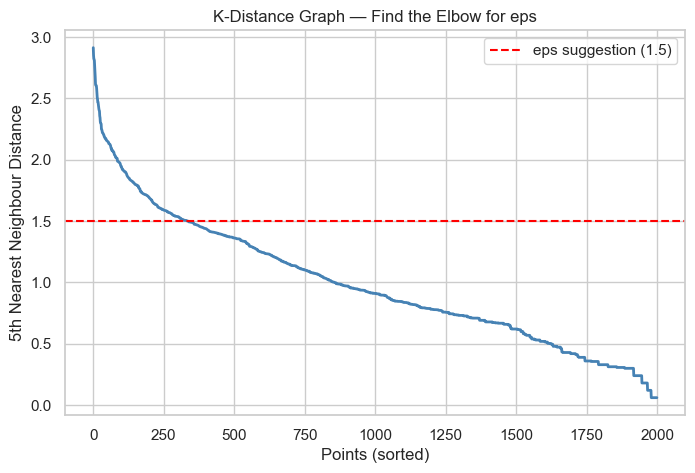

Look at the elbow in the graph — that point suggests your best eps value.


In [3]:
# Use a sample of 2000 rows for speed
sample_idx = np.random.choice(len(df_scaled), size=2000, replace=False)
df_sample  = df_scaled[sample_idx]

nbrs = NearestNeighbors(n_neighbors=5)
nbrs.fit(df_sample)
distances, _ = nbrs.kneighbors(df_sample)
kth_dist     = np.sort(distances[:, 4])[::-1]

plt.figure(figsize=(8, 5))
plt.plot(kth_dist, linewidth=2, color='steelblue')
plt.xlabel('Points (sorted)')
plt.ylabel('5th Nearest Neighbour Distance')
plt.title('K-Distance Graph — Find the Elbow for eps')
plt.axhline(y=1.5, color='red', linestyle='--', label='eps suggestion (1.5)')
plt.legend()
plt.savefig('data/dbscan_kdist.png', dpi=150, bbox_inches='tight')
plt.show()
print('Look at the elbow in the graph — that point suggests your best eps value.')

In [4]:
eps_values = [0.8, 1.0, 1.2, 1.5, 1.8, 2.0]
results    = []

print('Testing eps values on 2000-row sample...')
print(f'{"eps":>6}  {"clusters":>9}  {"noise":>7}  {"silhouette":>12}')
print('-' * 40)
for eps in eps_values:
    db_test  = DBSCAN(eps=eps, min_samples=5)
    lbl_test = db_test.fit_predict(df_sample)
    n_clust  = len(set(lbl_test)) - (1 if -1 in lbl_test else 0)
    n_noise  = list(lbl_test).count(-1)
    mask     = lbl_test != -1
    sil = silhouette_score(df_sample[mask], lbl_test[mask]) if n_clust >= 2 and mask.sum() > 1 else -1
    results.append({'eps': eps, 'clusters': n_clust, 'noise': n_noise, 'silhouette': round(sil, 4)})
    print(f'{eps:>6}  {n_clust:>9}  {n_noise:>7}  {sil:>12.4f}')

print('\n👉 Pick the eps with a reasonable cluster count (3–8) and highest silhouette score.')

Testing eps values on 2000-row sample...
   eps   clusters    noise    silhouette
----------------------------------------
   0.8         44      939        0.3369
   1.0         41      635        0.2150
   1.2         34      432        0.1740
   1.5         13      177        0.1397
   1.8          9       45        0.1623
   2.0          8       26        0.1716

👉 Pick the eps with a reasonable cluster count (3–8) and highest silhouette score.


In [5]:
# Set your chosen eps based on tuning above
EPS         = 1.5   # ← change this based on tuning results
MIN_SAMPLES = 5

print(f'Training DBSCAN: eps={EPS}, min_samples={MIN_SAMPLES} ...')
db        = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
db_labels = db.fit_predict(df_scaled)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise    = list(db_labels).count(-1)

print(f'\nClusters found : {n_clusters}')
print(f'Noise points   : {n_noise} ({n_noise/len(db_labels)*100:.1f}%)')
print('\nCluster sizes:')
unique, counts = np.unique(db_labels, return_counts=True)
for u, c in zip(unique, counts):
    label = 'Noise (-1)' if u == -1 else f'Cluster {u}'
    print(f'  {label}: {c} customers')

Training DBSCAN: eps=1.5, min_samples=5 ...

Clusters found : 9
Noise points   : 121 (1.5%)

Cluster sizes:
  Noise (-1): 121 customers
  Cluster 0: 822 customers
  Cluster 1: 1380 customers
  Cluster 2: 1940 customers
  Cluster 3: 860 customers
  Cluster 4: 742 customers
  Cluster 5: 938 customers
  Cluster 6: 756 customers
  Cluster 7: 501 customers
  Cluster 8: 8 customers


In [6]:
mask = db_labels != -1
sil  = silhouette_score(df_scaled[mask], db_labels[mask]) if n_clusters >= 2 and mask.sum() > 1 else -1
dbs  = davies_bouldin_score(df_scaled[mask], db_labels[mask]) if n_clusters >= 2 and mask.sum() > 1 else -1

print('=== DBSCAN Evaluation ===')
print(f'eps                 : {EPS}')
print(f'min_samples         : {MIN_SAMPLES}')
print(f'Clusters found      : {n_clusters}')
print(f'Noise points        : {n_noise}')
print(f'Silhouette Score    : {sil:.4f}  (higher = better)')
print(f'Davies-Bouldin Score: {dbs:.4f}  (lower  = better)')

scores = {'algorithm': 'DBSCAN', 'n_clusters': n_clusters,
          'silhouette': round(sil, 4), 'davies_bouldin': round(dbs, 4),
          'inertia': 'N/A', 'noise': n_noise}
pickle.dump(scores,    open('data/dbscan_scores.pkl', 'wb'))
pickle.dump(db_labels, open('data/dbscan_labels.pkl', 'wb'))
pickle.dump(db,        open('data/dbscan_model.pkl',  'wb'))
print('\n✅ Scores saved!')

=== DBSCAN Evaluation ===
eps                 : 1.5
min_samples         : 5
Clusters found      : 9
Noise points        : 121
Silhouette Score    : 0.1589  (higher = better)
Davies-Bouldin Score: 1.9715  (lower  = better)

✅ Scores saved!


Variance explained: 41.1%


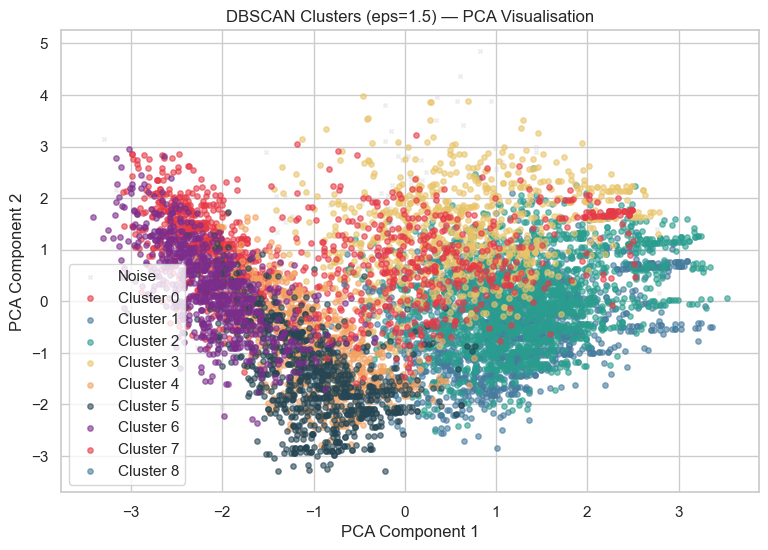

In [7]:
pca    = PCA(n_components=2, random_state=42)
df_pca = pca.fit_transform(df_scaled)
print(f'Variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%')

colors = ['#E63946','#457B9D','#2A9D8F','#E9C46A','#F4A261','#264653','#7B2D8B']

plt.figure(figsize=(9, 6))
for label in sorted(set(db_labels)):
    mask = db_labels == label
    if label == -1:
        plt.scatter(df_pca[mask, 0], df_pca[mask, 1],
                    s=8, c='lightgray', marker='x', label='Noise', alpha=0.4)
    else:
        plt.scatter(df_pca[mask, 0], df_pca[mask, 1],
                    s=15, color=colors[label % len(colors)],
                    label=f'Cluster {label}', alpha=0.6)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title(f'DBSCAN Clusters (eps={EPS}) — PCA Visualisation')
plt.legend()
plt.savefig('data/dbscan_pca.png', dpi=150, bbox_inches='tight')
plt.show()

=== Cluster Profiles (excluding noise) ===
         Gender  Ever_Married    Age  Graduated  Profession  Work_Experience  \
Cluster                                                                        
0           0.0           0.0  26.02        0.0        4.10             2.17   
1           1.0           1.0  51.64        1.0        1.92             2.30   
2           0.0           1.0  51.21        1.0        2.20             2.18   
3           0.0           1.0  51.14        0.0        3.29             1.94   
4           0.0           0.0  35.91        1.0        2.27             3.02   
5           1.0           0.0  37.59        1.0        2.41             3.27   
6           1.0           0.0  28.29        0.0        3.88             2.66   
7           1.0           1.0  50.72        0.0        3.19             2.14   
8           1.0           1.0  29.38        0.0        6.00             9.88   

         Spending_Score  Family_Size  Var_1  
Cluster                       

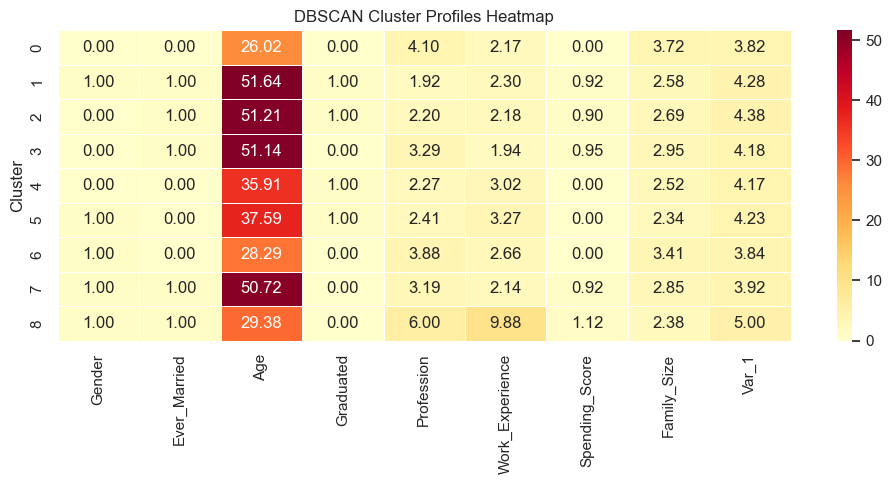

In [8]:
# Cluster profiles (exclude noise)
df_result   = df_clean.copy()
df_result['Cluster'] = db_labels
df_no_noise = df_result[df_result['Cluster'] != -1]

print('=== Cluster Profiles (excluding noise) ===')
profile = df_no_noise.groupby('Cluster').mean().round(2)
print(profile)

plt.figure(figsize=(10, 5))
sns.heatmap(profile, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
plt.title('DBSCAN Cluster Profiles Heatmap')
plt.tight_layout()
plt.savefig('data/dbscan_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
print('=' * 55)
print('   DBSCAN: Predict Cluster for a New Customer')
print('=' * 55)
print('Note: DBSCAN may label unusual customers as Noise (-1)\n')
print('Profession codes : 0=Artist, 1=Doctor, 2=Engineer,')
print('                   3=Entertainment, 4=Executive,')
print('                   5=Healthcare, 6=Homemaker,')
print('                   7=Lawyer, 8=Marketing')
print('Var_1 codes      : 0 to 6 (category code)')
print()

age            = float(input('Age (e.g. 30): '))
gender         = float(input('Gender        — Male=0, Female=1: '))
ever_married   = float(input('Ever Married  — No=0, Yes=1: '))
graduated      = float(input('Graduated     — No=0, Yes=1: '))
profession     = float(input('Profession    — (enter code 0–8): '))
work_exp       = float(input('Work Experience (years, e.g. 5): '))
spending_score = float(input('Spending Score — Low=0, Average=1, High=2: '))
family_size    = float(input('Family Size   (e.g. 3): '))
var_1          = float(input('Var_1         — (enter code 0–6): '))

user_data   = np.array([[age, gender, ever_married, graduated,
                          profession, work_exp, spending_score,
                          family_size, var_1]])
user_scaled = scaler.transform(user_data)

# DBSCAN has no built-in predict — find nearest core point
core_samples = df_scaled[db.core_sample_indices_]
core_labels  = db_labels[db.core_sample_indices_]

nbrs_pred         = NearestNeighbors(n_neighbors=1).fit(core_samples)
distance, idx     = nbrs_pred.kneighbors(user_scaled)
predicted_cluster = core_labels[idx[0][0]] if distance[0][0] <= EPS else -1

print()
print('=' * 55)
if predicted_cluster == -1:
    print('  ⚠️  Predicted: NOISE — customer does not fit any cluster')
    print('     (too different from all existing customer groups)')
else:
    print(f'  ✅ Predicted Cluster: Cluster {predicted_cluster}')
print('=' * 55)

if predicted_cluster != -1:
    profile = df_no_noise.groupby('Cluster').mean().round(2)
    print(f'\nAverage profile of Cluster {predicted_cluster}:')
    print(profile.loc[predicted_cluster].to_string())
    print('\n👉 This customer belongs to the group above.')

   DBSCAN: Predict Cluster for a New Customer
Note: DBSCAN may label unusual customers as Noise (-1)

Profession codes : 0=Artist, 1=Doctor, 2=Engineer,
                   3=Entertainment, 4=Executive,
                   5=Healthcare, 6=Homemaker,
                   7=Lawyer, 8=Marketing
Var_1 codes      : 0 to 6 (category code)



Age (e.g. 30):  20
Gender        — Male=0, Female=1:  1
Ever Married  — No=0, Yes=1:  0
Graduated     — No=0, Yes=1:  1
Profession    — (enter code 0–8):  3
Work Experience (years, e.g. 5):  4
Spending Score — Low=0, Average=1, High=2:  2
Family Size   (e.g. 3):  2
Var_1         — (enter code 0–6):  1



  ⚠️  Predicted: NOISE — customer does not fit any cluster
     (too different from all existing customer groups)
